In [1]:
from glob import glob



for g in glob('../data/*.pdf'):
    print(g)

../data\2040_seoul_plan.pdf
../data\OneNYC_2050_Strategic_Plan.pdf


In [1]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter



def read_pdf_and_split_text(pdf_path, chunk_size = 1000, chunk_overlap=100):
    """
    주어진 pdf파일을 읽고 텍스트를 분할합니다.
    
    매개변수:
        pdf_path(str): pdf파일의 경로
        chunk_size(int, 선택적): 각 텍스트 청크의 크기. 기본값은 1000입니다.
        chunk_overlap(int, 선택적): 청크 간의 중첩 크기. 기본값은 100입니다.
    반환값:
        list: 분할된 텍스트 청크의 리스트.    
    """

    print(f"PDF: {pdf_path}---------------------------")

    pdf_loader = PyPDFLoader(pdf_path)
    data_from_pdf = pdf_loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap
    )

    splits = text_splitter.split_documents(data_from_pdf)

    print(f"Number of splits: {len(splits)}\n")

    return splits

In [2]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
import os



embedding = OpenAIEmbeddings(model='text-embedding-3-large')

persist_directory='../chroma_store'

if os.path.exists(persist_directory):
    print("Loading existing Chroma store")
    vectorstore = Chroma(
        persist_directory=persist_directory,
        embedding_function=embedding
    )
else:
    print("Creating new Chroma store")

    vectorstore = None

    for g in glob('../data/*.pdf'):
        chunks = read_pdf_and_split_text(g)

        for i in range(0, len(chunks), 100):
            if vectorstore is None:
                vectorstore = Chroma.from_documents(
                    documents=chunks[i::i+100],
                    embedding=embedding,
                    persist_directory=persist_directory,
                )
            else:
                vectorstore.add_documents(
                    documents=chunks[i::i+100]
                )

Loading existing Chroma store


In [3]:
retriever = vectorstore.as_retriever(search_kwargs={'k': 5})

chunks = retriever.invoke('서울 쓰레기 처리 계획')

for chunk in chunks:
    print(chunk.metadata)
    print(chunk.page_content)

{'producer': 'Hancom PDF 1.3.0.542', 'creator': 'Hwp 2020 11.0.0.5178', 'creationdate': '2024-12-12T18:16:11+09:00', 'page_label': '88', 'source': '../data\\2040_seoul_plan.pdf', 'page': 87, 'author': 'SI', 'total_pages': 205, 'moddate': '2024-12-12T18:16:11+09:00', 'pdfversion': '1.4'}
Ÿ소규모 분산형 발전시설 확대를 위한 대체에너지 설치 지원을 지속적으로 확대하고, 공공시설의 옥상 및 주차장 등의 공간을 활용하여 지역 내에서 에너지를 생산·관리할 수 있는 기반을 마련한다.Ÿ지역에서 생산된 에너지 중 사용하고 남은 전력을 손쉽게 거래하여 순환 에너지 경제 기반이 확대될 수 있도록 법적·제도적으로 지원한다.3-1-4 대기 환경을 고려한 공간계획과 배출원 관리체계 강화Ÿ서울의 대기 환경용량과 자연적인 대기순환을 고려한 정비 및 개발 계획을 수립한다. -자연적인 대기순환을 고려한 건축물 배치, 바람길 확보 등 가이드라인에 따라 구역 내 시설물을 정비하고 개발할 수 있도록 유도Ÿ배출원별, 계절별 배출 특성을 고려하는 한편, 생활환경 변화에 대응하는 서울시 맞춤형 대책을 추진하여 PM2.5, NOx 등 대기오염물질의 배출을 원천적으로 감축한다.3-2 건강한 순환도시 조성을 위한 자립적인 자원순환 체계 구축3-2-1 자원순환·관리 자립을 위한 분산형 폐기물처리 시설 구축Ÿ외부에 의존하던 폐기물처리에서 벗어나 자원순환관리의 자립을 지향하기 위해 생활권 단위부터 광역 단위까지 공간단위별 차등화된 분산형 복합자원순환시설을 확충한다. -지역 맞춤형 자원재활용 체계를 마련하는 완결형 순환도시는 보행일상권을 기반으로 추진-보행일상권 단위에서 배출되는 폐기물의 감량 및 재사용·재활용 등 처리 인프라를 확충하여 시민이 자발적으로 참여할 수 있는 기반 마련-자치구

In [4]:
from langchain_openai import ChatOpenAI



model = ChatOpenAI(model='gpt-4o-mini')

In [5]:
# 라우터 설정
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal
from pydantic import BaseModel, Field



class RouteQuery(BaseModel):
    """사용자 쿼리를 가장 관련성이 높은 데이터 소스로 라우팅합니다."""

    datasource: Literal["vectorstore", "casual_talk"] = Field(
        ...,
        description="""
        - casual_talk : 일상 대화를 위한 데이터 소스. 사용자가 일상적인 질문을 할 때 사용합니다.
        - vectorstore: 사용자 질문에 답하기 위해 RAG로 vectorstore검색이 필요한 경우 사용합니다.
        """,
    )

    

In [6]:
structured_llm_router = model.with_structured_output(RouteQuery)

router_system = """
당신은 사용자의 질문을 vectorstore 또는 casual_talk으로 라우팅하는 전문가입니다.
- vectorstore에는 서울, 뉴욕의 발전계획과 관련된 문서가 포함되어 있습니다. 이 주제에 대한 질문에는 vectorstore를 사용하십시오.
- 사용자의 질문이 일상 대화에 관련된 경우 casual_talk을 사용하십시오.
"""

route_prompt = ChatPromptTemplate.from_messages([
    ("system", router_system),
    ("human", "{question}"),
])

question_router = route_prompt | structured_llm_router

In [7]:
from langchain_core.prompts import PromptTemplate



class GradeDocuments(BaseModel):
    """검색된 문서가 질문과 관련성이 있는지 yes 또는 no로 평가합니다."""

    binary_score: Literal["yes", "no"] = Field(
        ...,
        description="문서가 질문과 관련이 있는지 여부를 'yes' 또는 'no'로 평가합니다."
    )

structured_llm_grader = model.with_structured_output(GradeDocuments)

In [8]:
grader_prompt = PromptTemplate.from_template("""
당신은 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 평가자입니다.
문서에 사용자 질문과 관련된 키워드 또는 의미가 포함되어 있으면, 해당 문서를 관련성이 있다고 평가하십시오.
엄격한 테스트가 필요하지 않습니다.
목표는 잘못된 검색 결과를 걸러내는 것입니다.
문서가 질문과 관련이 있는지 여부를 나타내기 위해 'yes' 또는 'no'로 이진 점수를 부여하십시오.

Retrieved document: {document}

User question: {question}
                                            
""")                                        

retrieval_grader = grader_prompt | structured_llm_grader

question = '서울시 자율주행 관련 계획'

documents = retriever.invoke(question)

for doc in documents:
    print(doc)
                                                                                                                                              
                                            

page_content='54제2장 미래상과 목표
5. 기술발전에 선제적 대응, ‘미래교통 인프라 구축’1) 배경미래교통수단 도입에 따른 도시 활동 변화 및 공간구조 재편 대비Ÿ빠르게 진화하는 미래 신 교통수단은 도시공간에 새로운 변화를 일으킬 것이며, 도시 내 이동패턴의 변화를 가져올 것으로 예측된다. 이러한 점을 고려하여 도시 내 다양한 통행행태가 공존하는 포용적인 교통체계 구축을 준비해야 한다.미래교통수단 정착을 위한 도시 인프라 확충지원 필요Ÿ기존에 없던 새로운 교통은 통상 인프라 구축에 많은 시간이 소요되기 때문에 교통수단이 도입된 이후에 준비하기보다는 개발단계에서부터 이를 지원하기 위한 교통인프라 구축 구상이 요구되며, 새로운 도시 인프라 확충에 대한 도시계획적 지원이 필요하다.2) 추진전략자율주행 자동차 본격 운영 체계 구축Ÿ자율주행은 현재 제일 가시화되고 있는 미래 교통기술로 시장의 주도권을 확보하기 위해 각국의 노력이 집중되고 있다. 단계적으로 2030년까지 간선도로급 이상 도로에서 운영할 수 있는 도로 인프라 환경을 조성하고, 2040년까지 서울 전역 자율주행 운행 환경 구축을 목표로 한다.-2040년까지 서울 전역 자율주행차량의 운행 환경을 구축하고 수송 분담률 10%를 달성서울형 도심 항공교통 기반 마련 및 터미널 확충Ÿ도심에서 김포공항까지 시범노선을 운영하는 등 상용화 노선을 확보하고, 장기적으로 한강, 지천 등 주요 수변 공간 중심으로 광역노선을 확보한다. 또한 UAM 인프라 확보를 위한 인센티브 및 도시계획적인 지원 방안도 함께 검토한다.-UAM 시범노선을 운영하고, 한강 등 주요 수변 공간 중심에 단계적 광역노선을 확장서울 전역에 모빌리티 허브 구축Ÿ도심 및 광역거점에 서울 내부와 외부의 연계를 위한 미래 교통과 기존 교통을 연결하는 시설을 도입한다. 또한 교통뿐 아니라 공공서비스, 물류, 상업 등 다양한 기능들이 복합적으로 제공되는 지역 거점 모빌리티 허브를 서울 전역에 도입한다.' metadata={'producer': 'Han

In [10]:
filtered_docs = []

for i, doc in enumerate(documents):
    print(f"documents {i+1}:")
    is_relevant = retrieval_grader.invoke({"question": question, "document" : doc.page_content})
    print(is_relevant)
    print(doc.page_content[:200])
    print("============================================\n\n")

    if is_relevant.binary_score == "yes":
        filtered_docs.append(doc)

print(f"Filtered documents: {len(filtered_docs)}")

documents 1:
binary_score='yes'
54제2장 미래상과 목표
5. 기술발전에 선제적 대응, ‘미래교통 인프라 구축’1) 배경미래교통수단 도입에 따른 도시 활동 변화 및 공간구조 재편 대비Ÿ빠르게 진화하는 미래 신 교통수단은 도시공간에 새로운 변화를 일으킬 것이며, 도시 내 이동패턴의 변화를 가져올 것으로 예측된다. 이러한 점을 고려하여 도시 내 다양한 통행행태가 공존하는 포용적인 교통체계 구


documents 2:
binary_score='yes'
36제2장 미래상과 목표
6) 미래교통수단의 등장과 첨단 인프라 요구 증대자율주행, UAM 등 미래 교통에 공간적 대응방안 마련 필요Ÿ자율주행차량, 전동킥보드 등 교통 기술의 발전에 따라 새로운 교통환경이 조성되고 있음에도 불구하고, 이에 대한 정착 가이드라인이 없어, 위험한 교통 사고가 유발되고 있다.-최근 3년간 서울시에서 발생한 전동킥보드 관련 사고 


documents 3:
binary_score='no'
제1절 도시공간구조105기능이 공존하는 미래 도심으로 조성-국제 디지털 금융중심지인 여의도·영등포는 한강을 중심으로 한 글로벌 혁신코어 조성-국제 업무 중심지인 강남은 영동대로와 경부간선도로의 입체복합화로 가용지를 확보하여 업무복합기능을 강화 Ÿ수도 서울의 위상 강화를 위해 “광화문~용산~영등포”축을 국가중심공간으로 조성한다.-북악산~청와대~광화문광장~서울


documents 4:
binary_score='no'
제3절 권역별 구상147보행 중심 교통체계 전환을 위한 친환경 교통 인프라 구축 및 제도 개선 Ÿ주차상한제 강화, 공해 차량 통행 제한 확대, 탄력적인 주차요금제 적용 등으로 도심 내 승용차 수요관리 체계를 정립하고 도심 우회도로를 조속히 확충하여 서울도심 내 도로·교통시설체계를 재편한다.Ÿ신분당선 서북부연장 등 도시철도망을 확대하고 간선급행버스(BRT) 


documents 5:
binary_score='no'
광화문·시청역을, GTX-B 노선은 종로3가역 또는 동대

In [11]:
rag_generate_system = """
너는 사용자의 질문에 대해 주어진 context에 기반하여 답변하는 도시 계획 전문가이다.
주어진 context는 vectorstore에서 검색된 결과이다.
주어진 context를 기반으로 사용자의 question에 대해 답변하라.

================================
question: {question}
context: {context}
"""

rag_prompt = PromptTemplate(
    input_variables=["question", "context"],
    template=rag_generate_system
)

rag_chain = rag_prompt | model

question = "서울시 자율주행 관련 계획"

rag_chain.invoke({"question":question, "context":filtered_docs})

AIMessage(content='서울시의 자율주행 관련 계획은 2030년까지 간선도로급 이상 도로에서 자율주행차가 운영될 수 있는 인프라를 조성하고, 2040년까지 서울 전역에서 자율주행 운행 환경을 구축하는 것을 목표로 합니다. 이 계획에 따라 자율주행 차량의 수송 분담률을 10%까지 달성하는 것이 목표입니다.\n\n또한, 서울시는 도심 항공 교통(UAM) 기반을 마련하고, 터미널을 확충하며, 시범노선을 운영하는 등의 활동을 통해, 한강 및 기타 주요 수변 공간에 광역노선을 확보할 계획입니다. 여기에 더해, 서울 전역에 모빌리티 허브를 구축하여 공공 서비스 및 물류, 상업 등 다양한 기능을 복합적으로 제공하는 교통 시설도 도입할 예정입니다.\n\n이러한 계획들은 자율주행, 전동킥보드 등 새로운 교통수단의 등장으로 인해 변화하는 도시 공간 및 이동 패턴에 선제적으로 대응하고자 하는 노력의 일환으로 볼 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 244, 'prompt_tokens': 1481, 'total_tokens': 1725, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_72a33e2aa6', 'id': 'chatcmpl-DgU8sxumfYVkHKqs9WTyXzVmOFpZF', 'service_tier': 'default', 'fin

In [12]:
from typing import List
from typing_extensions import TypedDict



class GraphState(TypedDict):
    question: str
    generation: str
    documents: List[str]

In [13]:
def route_question(state):
    """
    사용자 질문을 vectorstore 또는 casual_talk로 라우팅합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 라우팅된 데이터 소스와 사용자 질문을 포함하는 새로운 graph state
    """

    print('------ROUTE------')

    question = state['question']
    route = question_router.invoke({"question": question})

    print(f"---Routng to {route.datasource}---")
    return route.datasource

In [14]:
def retrieve(state):
    """
    vectorstore에서 질문에 대한 문서를 검색합니다.

    Args:
        state(dict) : 현재 graph state

    return:
        state(dict) : 검색된 문서와 사용자 질문을 포함하는 새로운 graph state
    """

    print('------RETRIEVE------')
    question = state['question']

    documents = retriever.invoke(question)
    return {"documents": documents, "question":question}

In [15]:
def grade_documents(state):
    """
    검색된 문서를 평가하여 질문과 관련성이 있는지 확인합니다.

    Args:
        state(dict): 현재 graph state

    return:
        state(dict): 관련성이 있는 문서와 사용자 질문을 포함하는 새로운 graph state
    """

    print('------GRADE------')
    question = state['question']
    documents = state['documents']
    filtered_docs = []

    for i, doc in enumerate(documents):
        is_relevant = retrieval_grader.invoke({"question": question, "document":doc.page_content})
        if is_relevant.binary_score == "yes":
            filtered_docs.append(doc)
    return {"documents": filtered_docs, "question":question}


In [16]:
def generate(state):
    """
    LLM을 사용하여 문서와 사용자 질문에 대한 답변을 생성합니다.

    Args:
        state(dict): 현재 graph state

    return:
        state(dict): LLM 생성 결과와 사용자 질문을 포함하는 새로운 graph state
    """

    print('------GENERATE------')
    question = state['question']
    documents = state['documents']
    generation = rag_chain.invoke({"question": question, "context": documents})
    return {
        "documents":documents,
        "question":question,
        "generation":generation
    }

In [18]:
def casual_talk(state):
    """
    일상 대화를 위한 답변을 생성합니다.

    Args:
        state(dict): 현재 graph state

    return:
        state(dict): 일상 대화 결과와 사용자 질문을 포함하는 새로운 graph state
    """

    print('------CASUAL TALK------')
    question = state['question']
    generation = model.invoke(question)
    return {
        "question": question,
        "generation":generation
    }

In [19]:
from langgraph.graph import START, StateGraph, END

workflow = StateGraph(GraphState)

In [20]:
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("casual_talk", casual_talk)


In [ ]:
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "vectorstore":"retrieve",
        "casual_talk":"casual_talk"
    }
)

workflow.add_edge("casual_talk", END)
workflow.add_edge("retrieve", "grade_documents")
workflow.add_edge("grade_documents", "generate")
workflow.add_edge("generate", END)



ValueError: Branch with name `route_question` already exists for node `__start__`

In [26]:
app = workflow.compile()

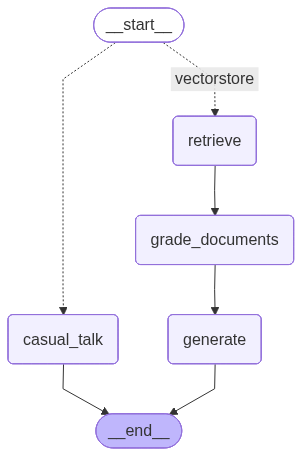

In [27]:
from IPython.display import Image, display


try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [28]:
inputs = {
    "question" : "서울시 자율주행 계획"
}

app.invoke(inputs)

------ROUTE------
---Routng to vectorstore---
------RETRIEVE------
------GRADE------
------GENERATE------


{'question': '서울시 자율주행 계획',
 'generation': AIMessage(content='서울시의 자율주행 계획은 2040년까지 서울 전역에 자율주행 차량의 운행 환경을 구축하고, 수송 분담률을 10% 달성하는 것을 목표로 하고 있습니다. 이러한 목표를 달성하기 위해 2030년까지 간선도로급 이상 도로에서 자율주행차가 운영될 수 있는 인프라 환경을 단계적으로 조성할 계획입니다.\n\n또한, 도심 항공교통(UAM)을 포함한 미래 교통체계를 위한 다양한 전략이 마련되고 있습니다. 예를 들어, 시범노선을 운영하며 한강과 같은 주요 수변 공간에 광역노선을 확장하고, 모빌리티 허브를 구축하여 도심과 외부 연계를 강화할 예정입니다. 이를 통해 공공서비스, 물류, 상업 등의 기능이 복합적으로 제공되는 지역 거점을 마련함으로써 서울 내 다양한 교통수단이 통합적으로 운영될 수 있도록 지원할 계획입니다.\n\n이와 같은 추진전략은 빠르게 진화하는 미래교통수단의 도입에 대비하기 위해 필요한 도시 인프라의 확충과 새로운 교통체계의 정착을 목표로 하고 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 260, 'prompt_tokens': 1480, 'total_tokens': 1740, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_791df6ace0

In [29]:
inputs = {
    "question":"잘지내고있어?"
}

app.invoke(inputs)

------ROUTE------
---Routng to casual_talk---
------CASUAL TALK------


{'question': '잘지내고있어?',
 'generation': AIMessage(content='네, 잘 지내고 있습니다! 당신은 어떻게 지내고 계신가요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 14, 'total_tokens': 33, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_72a33e2aa6', 'id': 'chatcmpl-DgUrOwwe0mUWTpLxlVFGF34v9YuPX', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e35e6-bab7-7de1-969c-d31a583b4dba-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 19, 'total_tokens': 33, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}

In [30]:
inputs = {
    "question":"서울시의 담배관련한 정책들과 계획은 어떤게 있나요?"
}

for msg, meta in app.stream(inputs, stream_mode="messages"):
    print(msg.content, end='')

------ROUTE------
{"datasource":"vectorstore"}---Routng to vectorstore---
------RETRIEVE------


c:\Users\hoyon\OneDrive\바탕 화면\Develope\InProgress\LLM_AI_Agent\chap13\venv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteQuery(datasource='vectorstore'), input_type=RouteQuery])
  return self.__pydantic_serializer__.to_python(


------GRADE------
{"binary_score":"no"}

c:\Users\hoyon\OneDrive\바탕 화면\Develope\InProgress\LLM_AI_Agent\chap13\venv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeDocuments(binary_score='no'), input_type=GradeDocuments])
  return self.__pydantic_serializer__.to_python(


{"binary_score":"no"}{"binary_score":"no"}{"binary_score":"no"}{"binary_score":"no"}------GENERATE------
주어진 context가 비어 있기 때문에 구체적인 정책이나 계획에 대한 정보를 제공할 수 없습니다. 그러나 일반적으로 서울시는 담배와 관련하여 여러 정책을 시행하고 있습니다. 예를 들어:

1. **공공장소 금연**: 특정 공공장소(예: 공원, 어린이 보호구역)에서의 흡연을 금지하는 정책이 있습니다.

2. **흡연구역 지정**: 서울시의 많은 지역에서는 흡연구역이 지정되어 있으며, 흡연구역 내에서만 흡연이 허용됩니다.

3. **금연 캠페인**: 대중의 흡연율을 줄이기 위한 다양한 공익광고와 교육 캠페인을 운영하고 있습니다.

4. **흡연율 감소 목표**: 서울시는 금연과 관련된 건강 증진 목표를 세우고, 흡연율을 낮추기 위한 지속적인 노력을 하고 있습니다.

구체적인 세부사항이나 최근의 변화에 대해서는 서울시 공식 웹사이트나 관련 기관의 발표를 참고하는 것이 좋습니다.